# Assignment 2 - AI: Deep Learning

In [94]:
# imports

import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np
import editdistance

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Using device    : {device}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.6.0+cpu
Using device    : cpu
CUDA available  : False


In [54]:
# Load and visualize data
training_data = pd.read_csv("data/g2p_train.csv")
training_data = training_data.dropna()


test_data = pd.read_csv("data/g2p_test.csv")
test_data = test_data.dropna()


val_data = pd.read_csv("data/g2p_val.csv")
val_data = val_data.dropna()

print(training_data.head())

        word                  phonemes
0      vigil            V IH1 JH AH0 L
1  ethelinda  EH0 TH EH0 L IY1 N D AH0
2      yaney               Y EY1 N IY0
3   caniglia   K AH0 N IH1 G L IY0 AH0
4     sondra           S AA1 N D R AH0


In [55]:
special_chars = ["<PAD>", "<SOS>", "<EOS>", "<UNKS>"]
char_vocab = {}

for id, char in enumerate(special_chars):
    char_vocab[char] = id
    
current_id = len(char_vocab)
for word in training_data["word"]:
    for char in word:
        if char in char_vocab:
            continue
        else:
            char_vocab[char] = current_id
            current_id += 1
            
print(char_vocab)


{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNKS>': 3, 'v': 4, 'i': 5, 'g': 6, 'l': 7, 'e': 8, 't': 9, 'h': 10, 'n': 11, 'd': 12, 'a': 13, 'y': 14, 'c': 15, 's': 16, 'o': 17, 'r': 18, 'u': 19, 'j': 20, 'k': 21, 'q': 22, 'p': 23, 'm': 24, 'b': 25, 'z': 26, 'f': 27, 'w': 28, 'x': 29}


In [56]:
# Build phoneme vocabulary
phoneme_vocab = {}
special_chars = ["<PAD>", "<SOS>", "<EOS>", "<UNKS>"]

for id, phoneme in enumerate(special_chars):
    phoneme_vocab[phoneme] = id

current_id = len(phoneme_vocab)
for phonemes in training_data["phonemes"]:
    phonemes = phonemes.split()
    for phoneme in phonemes:
        if phoneme in phoneme_vocab:
            continue
        else:
            phoneme_vocab[phoneme] = current_id
            current_id += 1
            
print(phoneme_vocab)
        

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNKS>': 3, 'V': 4, 'IH1': 5, 'JH': 6, 'AH0': 7, 'L': 8, 'EH0': 9, 'TH': 10, 'IY1': 11, 'N': 12, 'D': 13, 'Y': 14, 'EY1': 15, 'IY0': 16, 'K': 17, 'G': 18, 'S': 19, 'AA1': 20, 'R': 21, 'HH': 22, 'SH': 23, 'ER0': 24, 'T': 25, 'UW1': 26, 'AY1': 27, 'AE1': 28, 'NG': 29, 'W': 30, 'OW2': 31, 'P': 32, 'EH1': 33, 'AE2': 34, 'OW0': 35, 'M': 36, 'IH0': 37, 'Z': 38, 'CH': 39, 'B': 40, 'EH2': 41, 'OW1': 42, 'IY2': 43, 'AY2': 44, 'AA2': 45, 'F': 46, 'AO1': 47, 'AA0': 48, 'UW2': 49, 'ER1': 50, 'AO0': 51, 'AW0': 52, 'AH1': 53, 'IH2': 54, 'AY0': 55, 'AE0': 56, 'AH2': 57, 'ZH': 58, 'UH1': 59, 'EY0': 60, 'AO2': 61, 'AW2': 62, 'DH': 63, 'UW0': 64, 'OY1': 65, 'EY2': 66, 'AW1': 67, 'ER2': 68, 'UH2': 69, 'UH0': 70, 'OY2': 71, 'OY0': 72}


In [57]:
class WPPToIntegerSequence(Dataset):
    
    def __init__(self, data, char_vocab, phoneme_vocab):
        self.data = data
        self.char_vocab = char_vocab
        self.phoneme_vocab = phoneme_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        word = row["word"]
        phonemes = row["phonemes"]
        
        word_ids = []
        for char in word:
            if char in char_vocab:
                word_ids.append(char_vocab[char])
            else:
                word_ids.append(char_vocab["<UNK>"])
        
        phoneme_ids = [phoneme_vocab["<SOS>"]]
        for phoneme in phonemes.split():
            if phoneme in phoneme_vocab:
                phoneme_ids.append(phoneme_vocab[phoneme])        
            else:
                phoneme_ids.append(phoneme_vocab["<UNK>"])
        phoneme_ids.append(phoneme_vocab["<EOS>"])
        
        return (
            torch.tensor(word_ids, dtype=torch.long),
            torch.tensor(phoneme_ids, dtype=torch.long)
        )
        

In [58]:
def collate_fn(batch):
    src_batch = []
    tgt_batch = []

    for src, tgt in batch:
        src_batch.append(src)
        tgt_batch.append(tgt)

    src_padded = pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=0
    )

    tgt_padded = pad_sequence(
        tgt_batch,
        batch_first=True,
        padding_value=0
    )

    return src_padded, tgt_padded

In [59]:
train_dataset = WPPToIntegerSequence(training_data, char_vocab, phoneme_vocab)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

test_dataset = WPPToIntegerSequence(test_data, char_vocab, phoneme_vocab)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_dataset = WPPToIntegerSequence(val_data, char_vocab, phoneme_vocab)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)



In [60]:
print("Character vocabulary size:", len(char_vocab))
print("Phoneme vocabulary size:", len(phoneme_vocab))
print("Training set size:", len(training_data))

Character vocabulary size: 30
Phoneme vocabulary size: 73
Training set size: 92424


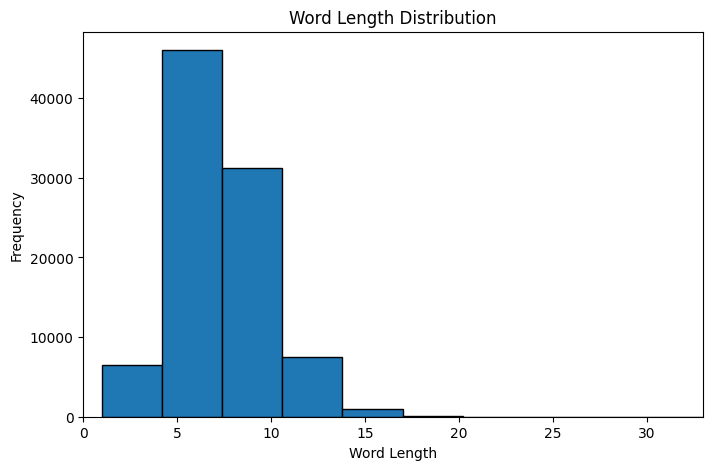

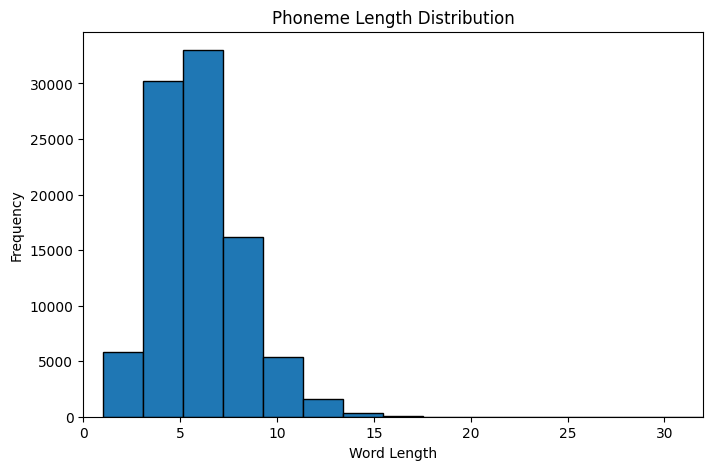

In [61]:
word_lengths = []

for word in training_data["word"]:
    word_lengths.append(len(word))
    
phoneme_lengths = []
for phonemes in training_data["phonemes"]:
    phoneme_lengths.append(len(phonemes.split()))
    
plt.figure(figsize=(8, 5))

plt.hist(word_lengths, bins=10, edgecolor="black")
plt.title("Word Length Distribution")
plt.xlim(0, max(word_lengths))
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(phoneme_lengths, bins=15, edgecolor="black")
plt.title("Phoneme Length Distribution")
plt.xlim(0, max(phoneme_lengths))
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

In [62]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat((x, h_prev), dim=1)

        f = torch.sigmoid(self.W_f(combined))
        i = torch.sigmoid(self.W_i(combined))
        o = torch.sigmoid(self.W_o(combined))
        c_tilde = torch.tanh(self.W_c(combined))

        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c

In [63]:
class ContextLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        combined_size = input_size + 2 * hidden_size

        self.W_f = nn.Linear(combined_size, hidden_size)
        self.W_i = nn.Linear(combined_size, hidden_size)
        self.W_o = nn.Linear(combined_size, hidden_size)
        self.W_c = nn.Linear(combined_size, hidden_size)

    def forward(self, x, h_prev, c_prev, z):
        combined = torch.cat((x, h_prev, z), dim=1)

        f = torch.sigmoid(self.W_f(combined))
        i = torch.sigmoid(self.W_i(combined))
        o = torch.sigmoid(self.W_o(combined))
        c_tilde = torch.tanh(self.W_c(combined))

        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c

In [64]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()
        self.src_vocab_size = src_vocab_size
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.lstm = LSTMCell(embed_dim, hidden_size)

    def forward(self, src):
        batch, src_len = src.shape
        x = self.embedding(src)
        h = torch.zeros(batch, self.hidden_size).to(device)
        c = torch.zeros(batch, self.hidden_size).to(device)
        all_h = []
        
        for t in range(src_len):
            h, c = self.lstm(x[:, t], h, c)
            all_h.append(h)
        all_h = torch.stack(all_h)
        
        return all_h, (h.unsqueeze(0), c.unsqueeze(0))
    # src: (batch, src_len)
    # Returns (all_h, (h_n, c_n))
    # all_h: (src_len, batch, hidden_size)
    # h_n, c_n: (num_layers, batch, hidden_sized
    

In [65]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = "none"):
        super().__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.context_mode = context_mode
        self.output_layer = nn.Linear(hidden_size, tgt_vocab_size)
        if context_mode == "none":
            self.lstm = LSTMCell(embed_dim, hidden_size)
        elif context_mode in ["fixed", "attn"]:
            self.lstm = ContextLSTMCell(embed_dim, hidden_size)
        else:
            raise ValueError("invalid context mode")

 
    # context_mode in {"none", "fixed", "attn"}
    def forward(self, tgt, hidden, encoder_outputs=None):
        h_n, c_n = hidden
        all_logits = []
        batch, tgt_len = tgt.shape
        
        h = h_n[0]
        c = c_n[0]
        x  = self.embedding(tgt)
        if self.context_mode == "fixed":
            z = h_n[0]
        for t in range(tgt_len):
            x_t = x[:, t]
            if self.context_mode=="none":
                h,c = self.lstm(x_t, h, c)
                
            elif self.context_mode=="fixed":
                h, c = self.lstm(x_t, h, c, z)
            elif self.context_mode == "attn":
                scores = torch.sum(encoder_outputs * h.unsqueeze(0), dim=2).transpose(0, 1)
                alpha = torch.softmax(scores, dim=1)
                z_t = torch.sum(alpha.transpose(0, 1).unsqueeze(2) * encoder_outputs, dim=0)
                h, c = self.lstm(x_t, h, c, z_t)

            logits = self.output_layer(h)
            all_logits.append(logits)
        
        all_logits = torch.stack(all_logits,1)
        return all_logits, (h.unsqueeze(0), c.unsqueeze(0))
    # tgt: (batch, tgt_len)
    # hidden: (h_0, c_0)
    # h_0, c_0: (num_layers, batch, hidden_size)
    # encoder_outputs: optional (only needed for attention)
    # (src_len, batch, hidden_size)
    #
    # Returns (logits, (h_n, c_n))
    # logits: (batch, tgt_len, tgt_vocab_size)
    # h_n, c_n: (num_layers, batch, hidden_size)

In [66]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        enc_outputs, hidden = self.encoder(src)
        dec_input = tgt[:,:-1]
        logits,_ = self.decoder(dec_input, hidden, enc_outputs) 
        return logits
    # Returns logits: (batch, tgt_len-1, tgt_vocab_size)
    def greedy_decode(self, src, max_len: int = 30):
        batch_size = src.shape[0]
        device = src.device

        enc_outputs, hidden = self.encoder(src)

        input_token = torch.full(
            (batch_size, 1),
            1, 
            dtype=torch.long,
            device=device
        )
        predictions = []

        for _ in range(max_len):
            logits, hidden = self.decoder(
                input_token,
                hidden,
                enc_outputs
            )

            next_token = logits[:, -1, :].argmax(dim=-1)

            predictions.append(next_token)

            input_token = next_token.unsqueeze(1)

        predictions = torch.stack(predictions, dim=1)
        return predictions

In [76]:
def train_eval_model(encoder, decoder, lr, num_epochs):
    training_losses = []
    val_losses = []
    model = Seq2Seq(encoder, decoder).to(device)

    loss_fn = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        for src, tgt in train_loader:
            src = src.to(device)
            tgt = tgt.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt)
            target = tgt[:, 1:]
            logits = logits[:, :target.size(1), :]
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
            loss.backward()
            
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            total_train_loss += loss.item()
            
        avg_train_loss = total_train_loss / len(train_loader)
        training_losses.append(avg_train_loss)
        
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for src, tgt in val_loader:
                src = src.to(device)
                tgt = tgt.to(device)
                logits = model(src, tgt)
                target = tgt[:, 1:]
                logits = logits[:, :target.size(1), :]
                loss = loss_fn(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
                total_val_loss += loss.item()
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch}/{num_epochs}, train loss: {avg_train_loss:.4f}")
        print(f"Epoch {epoch}/{num_epochs}, val loss: {avg_val_loss:.4f}")
    checkpoint = {
        "model_state": model.state_dict(),
        "encoder_state": encoder.state_dict(),
        "decoder_state": decoder.state_dict(),
        "char_vocab": char_vocab,
        "phoneme_vocab": phoneme_vocab,
        "lr": lr,
        "embed_dim": encoder.embedding.embedding_dim,
        "hidden_size": encoder.hidden_size,
        "num_epochs": num_epochs,
        "context_mode": decoder.context_mode,
        "training_losses": training_losses,
        "val_losses": val_losses,
    }

    filename = f"seq2seq_{decoder.context_mode}.pt"
    torch.save(checkpoint, filename)
    return training_losses, val_losses

In [68]:
# Training

num_epochs = 5
lr = 0.0001
encoder = Encoder(len(char_vocab), 128, 256, 1).to(device)
decoder_attn = Decoder(len(phoneme_vocab), 128, 256, 1, "attn").to(device)
decoder_fixed = Decoder(len(phoneme_vocab), 128, 256, 1, "fixed").to(device)
decoder_none = Decoder(len(phoneme_vocab), 128, 256, 1, "none").to(device)

attn_training_losses, attn_val_losses = train_eval_model(encoder, decoder_attn, lr, num_epochs=num_epochs)
fixed_training_losses, fixed_val_losses = train_eval_model(encoder, decoder_fixed, lr, num_epochs=num_epochs)
none_training_losses, none_val_losses = train_eval_model(encoder, decoder_none, lr, num_epochs=num_epochs)

Epoch 0/5, train loss: 2.6269
Epoch 0/5, val loss: 1.9482
Epoch 1/5, train loss: 1.5827
Epoch 1/5, val loss: 1.2964
Epoch 2/5, train loss: 1.1178
Epoch 2/5, val loss: 0.9829
Epoch 3/5, train loss: 0.8745
Epoch 3/5, val loss: 0.7820
Epoch 4/5, train loss: 0.7325
Epoch 4/5, val loss: 0.6754
Epoch 0/5, train loss: 1.9274
Epoch 0/5, val loss: 1.2298
Epoch 1/5, train loss: 1.0051
Epoch 1/5, val loss: 0.8375
Epoch 2/5, train loss: 0.7512
Epoch 2/5, val loss: 0.6713
Epoch 3/5, train loss: 0.6244
Epoch 3/5, val loss: 0.5771
Epoch 4/5, train loss: 0.5473
Epoch 4/5, val loss: 0.5221
Epoch 0/5, train loss: 2.0399
Epoch 0/5, val loss: 1.2756
Epoch 1/5, train loss: 1.0295
Epoch 1/5, val loss: 0.8495
Epoch 2/5, train loss: 0.7586
Epoch 2/5, val loss: 0.6764
Epoch 3/5, train loss: 0.6264
Epoch 3/5, val loss: 0.5816
Epoch 4/5, train loss: 0.5465
Epoch 4/5, val loss: 0.5180


[2.626925377367277, 1.582710898211258, 1.1178454976180845, 0.8744983989474683, 0.7324583395542158]


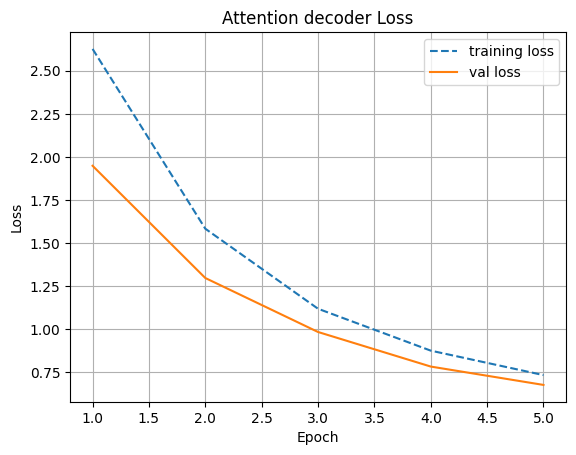

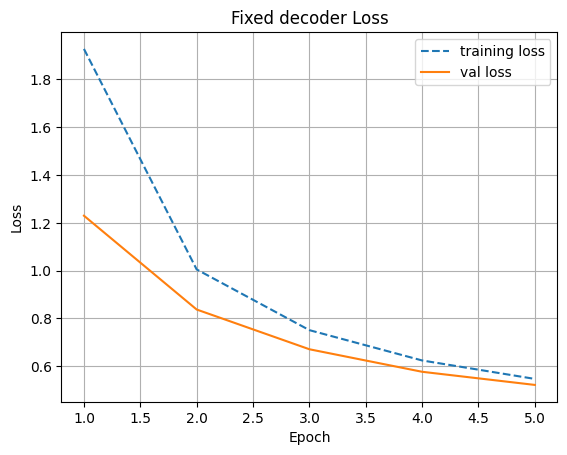

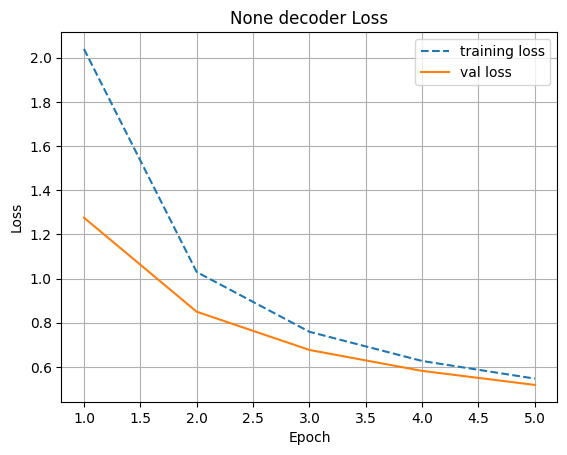

In [69]:
epochs = range(1, num_epochs+1)
print(attn_training_losses)
plt.figure()

plt.plot(epochs, attn_training_losses, '--', label='training loss')
plt.plot(epochs, attn_val_losses, label='val loss')

plt.title('Attention decoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()



plt.figure()

plt.plot(epochs, fixed_training_losses, '--', label='training loss')
plt.plot(epochs, fixed_val_losses, label='val loss')

plt.title('Fixed decoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()



plt.figure()

plt.plot(epochs, none_training_losses, '--', label='training loss')
plt.plot(epochs, none_val_losses, label='val loss')

plt.title('None decoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [70]:
# Hyperparameter tuning

num_epochs = 5
learning_rates = [0.00001, 0.0001, 0.001]
embed_dims = [32, 64, 128]
hidden_sizes = [64, 128, 256]
results = []

for lr in learning_rates:
    for embed_dim in embed_dims:
        for hidden_size in hidden_sizes:
            encoder = Encoder(len(char_vocab), embed_dim, hidden_size, 1).to(device)
            decoder = Decoder(len(phoneme_vocab), embed_dim, hidden_size, 1, context_mode = "none").to(device)
            training_losses, val_losses = train_eval_model(encoder, decoder, lr, num_epochs)
            results.append({
                "lr":lr,
                "embed_dim":embed_dim,
                "hidden_size":hidden_size,
                "val_loss:":val_losses[-1]
            })

Epoch 0/5, train loss: 4.1559
Epoch 0/5, val loss: 3.7617
Epoch 1/5, train loss: 3.4994
Epoch 1/5, val loss: 3.3994
Epoch 2/5, train loss: 3.3613
Epoch 2/5, val loss: 3.3296
Epoch 3/5, train loss: 3.3033
Epoch 3/5, val loss: 3.2702
Epoch 4/5, train loss: 3.2394
Epoch 4/5, val loss: 3.2067
Epoch 0/5, train loss: 3.8699
Epoch 0/5, val loss: 3.3693
Epoch 1/5, train loss: 3.3158
Epoch 1/5, val loss: 3.2770
Epoch 2/5, train loss: 3.2467
Epoch 2/5, val loss: 3.1987
Epoch 3/5, train loss: 3.1426
Epoch 3/5, val loss: 3.0966
Epoch 4/5, train loss: 3.0676
Epoch 4/5, val loss: 3.0352
Epoch 0/5, train loss: 3.6028
Epoch 0/5, val loss: 3.2707
Epoch 1/5, train loss: 3.1977
Epoch 1/5, val loss: 3.1358
Epoch 2/5, train loss: 3.0987
Epoch 2/5, val loss: 3.0576
Epoch 3/5, train loss: 3.0255
Epoch 3/5, val loss: 2.9897
Epoch 4/5, train loss: 2.9607
Epoch 4/5, val loss: 2.9268
Epoch 0/5, train loss: 4.1078
Epoch 0/5, val loss: 3.6788
Epoch 1/5, train loss: 3.4805
Epoch 1/5, val loss: 3.3877
Epoch 2/5, tra

In [73]:
df = pd.DataFrame(results)
df = df.sort_values(by="val_loss:")
print(df)

         lr  embed_dim  hidden_size  val_loss:
23  0.00100         64          256   0.305216
26  0.00100        128          256   0.311828
20  0.00100         32          256   0.317548
22  0.00100         64          128   0.409590
25  0.00100        128          128   0.427139
19  0.00100         32          128   0.446429
24  0.00100        128           64   0.646562
21  0.00100         64           64   0.662383
18  0.00100         32           64   0.663269
17  0.00010        128          256   0.731657
14  0.00010         64          256   0.855913
11  0.00010         32          256   1.085962
16  0.00010        128          128   1.105952
13  0.00010         64          128   1.304804
10  0.00010         32          128   1.564528
15  0.00010        128           64   1.647341
12  0.00010         64           64   1.768037
9   0.00010         32           64   2.170880
8   0.00001        128          256   2.553380
5   0.00001         64          256   2.673633
7   0.00001  

In [86]:
# Training 15 epochs with best hyper parameters

num_epochs = 15
lr = 0.0001
embed_dim = 64
hidden_size = 256
encoder = Encoder(len(char_vocab), embed_dim, hidden_size, 1).to(device)
decoder_attn = Decoder(len(phoneme_vocab), embed_dim, hidden_size, 1, "attn").to(device)
decoder_fixed = Decoder(len(phoneme_vocab), embed_dim, hidden_size, 1, "fixed").to(device)
decoder_none = Decoder(len(phoneme_vocab), embed_dim, hidden_size, 1, "none").to(device)

attn_training_losses, attn_val_losses = train_eval_model(encoder, decoder_attn, lr, num_epochs=num_epochs)
fixed_training_losses, fixed_val_losses = train_eval_model(encoder, decoder_fixed, lr, num_epochs=num_epochs)
none_training_losses, none_val_losses = train_eval_model(encoder, decoder_none, lr, num_epochs=num_epochs)

Epoch 0/15, train loss: 2.7940
Epoch 0/15, val loss: 2.1985
Epoch 1/15, train loss: 1.8191
Epoch 1/15, val loss: 1.5235
Epoch 2/15, train loss: 1.3244
Epoch 2/15, val loss: 1.1607
Epoch 3/15, train loss: 1.0479
Epoch 3/15, val loss: 0.9412
Epoch 4/15, train loss: 0.8790
Epoch 4/15, val loss: 0.8161
Epoch 5/15, train loss: 0.7652
Epoch 5/15, val loss: 0.7133
Epoch 6/15, train loss: 0.6807
Epoch 6/15, val loss: 0.6473
Epoch 7/15, train loss: 0.6157
Epoch 7/15, val loss: 0.5929
Epoch 8/15, train loss: 0.5648
Epoch 8/15, val loss: 0.5510
Epoch 9/15, train loss: 0.5228
Epoch 9/15, val loss: 0.5108
Epoch 10/15, train loss: 0.4875
Epoch 10/15, val loss: 0.4835
Epoch 11/15, train loss: 0.4577
Epoch 11/15, val loss: 0.4570
Epoch 12/15, train loss: 0.4327
Epoch 12/15, val loss: 0.4410
Epoch 13/15, train loss: 0.4104
Epoch 13/15, val loss: 0.4228
Epoch 14/15, train loss: 0.3907
Epoch 14/15, val loss: 0.4092
Epoch 0/15, train loss: 2.0793
Epoch 0/15, val loss: 1.3134
Epoch 1/15, train loss: 1.0490

In [87]:
# Loading trained models with best hyperparameters


def load_model_from_checkpoint(filepath):
    checkpoint = torch.load(filepath, map_location=device)
    encoder = Encoder(
        len(char_vocab),
        checkpoint["embed_dim"],
        checkpoint["hidden_size"],
        1
    ).to(device)
    decoder = Decoder(
        len(phoneme_vocab),
        checkpoint["embed_dim"],
        checkpoint["hidden_size"],
        1,
        checkpoint["context_mode"],
    ).to(device)

    encoder.load_state_dict(checkpoint["encoder_state"])
    decoder.load_state_dict(checkpoint["decoder_state"])

    model = Seq2Seq(encoder, decoder).to(device)
    model.eval()
    return model

In [88]:
model_attn = load_model_from_checkpoint("seq2seq_attn.pt")
model_fixed = load_model_from_checkpoint("seq2seq_fixed.pt")
model_none = load_model_from_checkpoint("seq2seq_none.pt")

In [89]:
pad_idx = phoneme_vocab["<PAD>"]
sos_idx = phoneme_vocab["<SOS>"]
eos_idx = phoneme_vocab["<EOS>"]

idx_to_phoneme = {}
for phoneme in phoneme_vocab.keys():
    idx_to_phoneme[phoneme_vocab[phoneme]] = phoneme

In [90]:
def indexes_to_phonemes(indexes):
    phonemes = []

    for idx in indexes:
        idx = int(idx)
        if idx == eos_idx:
            break
        if idx in [pad_idx, sos_idx]:
            continue
        phonemes.append(idx_to_phoneme[idx])

    return phonemes

In [91]:
def evaluate_model(model, test_loader):
    model.eval()

    total_per = 0
    correct_words = 0
    total_words = 0

    with torch.no_grad():
        for src, tgt in test_loader:
            src = src.to(device)
            tgt = tgt.to(device)
            logits = model(src, tgt)
            target = tgt[:, 1:]
            logits = logits[:, :target.size(1), :]
            preds = logits.argmax(dim=-1)
            batch_size = tgt.size(0)

            for i in range(batch_size):
                pred_phonemes = indexes_to_phonemes(preds[i])
                true_phonemes = indexes_to_phonemes(target[i])
                dist = editdistance.eval(pred_phonemes, true_phonemes)
                if len(true_phonemes) > 0:
                    total_per += dist / len(true_phonemes)
                if pred_phonemes == true_phonemes:
                    correct_words += 1
                total_words += 1

    avg_per = total_per / total_words
    word_accuracy = correct_words / total_words

    return avg_per, word_accuracy

In [98]:
avg_per, word_accuracy = evaluate_model(model_attn, test_loader)
print(f"ATTN --- PER: {avg_per:.5f}, Word accuracy: {word_accuracy:.5f}")

avg_per, word_accuracy = evaluate_model(model_fixed, test_loader)
print(f"FIXED --- PER: {avg_per:.5f}, Word accuracy: {word_accuracy:.5f}")

avg_per, word_accuracy = evaluate_model(model_none, test_loader)
print(f"NONE --- PER: {avg_per:.5f}, Word accuracy: {word_accuracy:.5f}")

ATTN --- PER: 0.13974, Word accuracy: 0.45101
FIXED --- PER: 0.11508, Word accuracy: 0.52129
NONE --- PER: 0.11522, Word accuracy: 0.51714
